In [1]:
import numpy as np
import pandas as pd
from scipy import stats

# Vector de datos brutos
duraciones = np.array([
    68.4, 69.8, 71.2, 72.0, 72.5, 73.1, 74.0, 74.8, 75.2, 75.9,
    76.1, 76.4, 76.7, 77.0, 77.3, 78.1, 78.5, 79.0, 80.2, 81.4,
    82.0, 83.3, 84.5, 85.6, 87.1
])

# Verificación de estadísticos
n = len(duraciones)
x_barra = np.mean(duraciones)
s = np.std(duraciones, ddof=1)
mu_0 = 80.0

# Prueba t de una muestra (dos colas)
t_stat, p_val = stats.ttest_1samp(duraciones, popmean=mu_0)

print(f"n = {n}")
print(f"Media (x̄) = {x_barra:.2f} h")
print(f"Desv. Estándar (s) = {s:.2f} h")
print(f"Estadístico t = {t_stat:.2f}")
print(f"Valor p = {p_val:.4f}")

n = 25
Media (x̄) = 77.20 h
Desv. Estándar (s) = 4.88 h
Estadístico t = -2.86
Valor p = 0.0086


<>:62: SyntaxWarning: invalid escape sequence '\p'
<>:62: SyntaxWarning: invalid escape sequence '\p'
C:\Users\jhquiza\AppData\Local\Temp\ipykernel_17664\777749871.py:62: SyntaxWarning: invalid escape sequence '\p'
  ax2.axvline(-t_crit, color='#b91c1c', linestyle=':', label=f'$t$ crítico = $\pm${t_crit:.3f}')


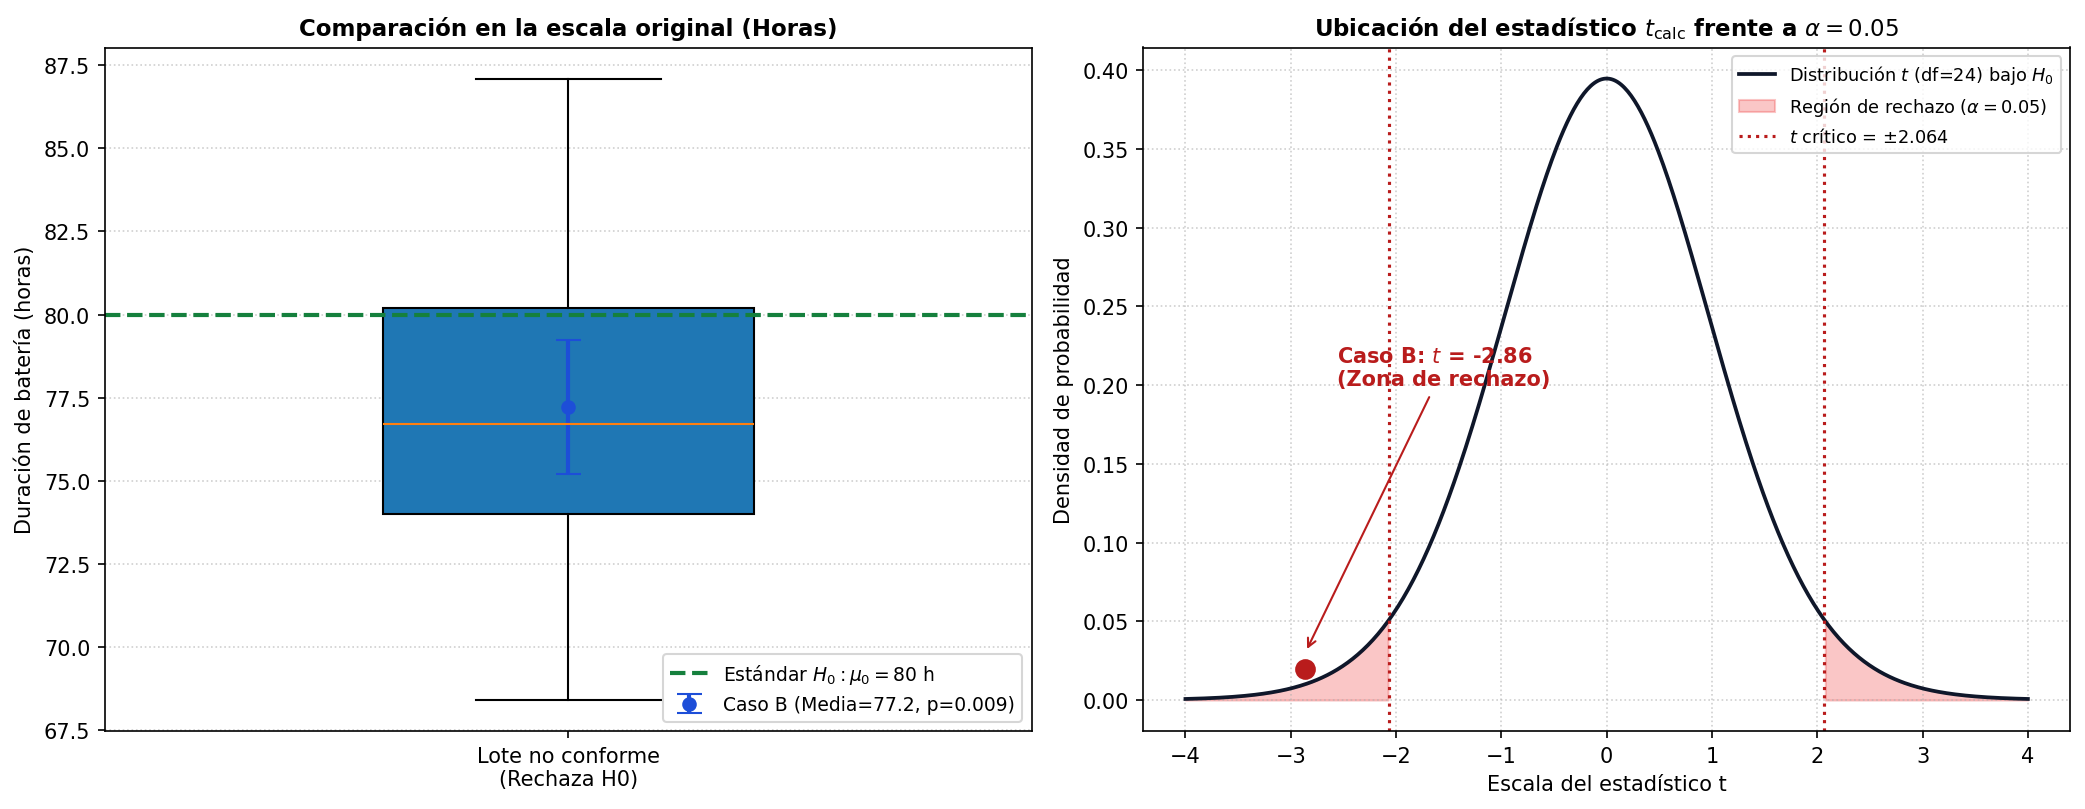

In [9]:
import scipy.stats as stats
import matplotlib.pyplot as plt


# 1. Datos de los dos casos
lote_rechazo = np.array([
    68.4, 69.8, 71.2, 72.0, 72.5, 73.1, 74.0, 74.8, 75.2, 75.9,
    76.1, 76.4, 76.7, 77.0, 77.3, 78.1, 78.5, 79.0, 80.2, 81.4,
    82.0, 83.3, 84.5, 85.6, 87.1
])

mu_0 = 80.0
df = len(lote_rechazo) - 1
t_crit = stats.t.ppf(0.975, df)

# Estadísticos
t_b, p_b = stats.ttest_1samp(lote_rechazo, mu_0)

# 2. Construcción del gráfico comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=150)

# --- Panel 1: Estimaciones puntuales e Intervalos del 95% ---
mean_b, se_b = np.mean(lote_rechazo), stats.sem(lote_rechazo)

# Diagrama de cajas ligero
ax1.boxplot(
    [lote_rechazo], 
    #positions=[1, 2], 
    widths=0.4,
    patch_artist=True, 
    #$boxprops=dict(facecolor='#f1f5f9', color='#64748b'),
    #medianprops=dict(color='#0f172a', linewidth=1.5)
    )

# Intervalos de confianza al 95% (t-Student)
#ax1.errorbar([1], [mean_a], yerr=[t_crit * se_a], fmt='o', color='#b91c1c', 
#             capsize=6, elinewidth=2, label=f'Caso A (Media={mean_a:.1f}, p={p_a:.3f})')
ax1.errorbar([1], [mean_b], yerr=[t_crit * se_b], fmt='o', color='#1d4ed8', 
             capsize=6, elinewidth=2, label=f'Caso B (Media={mean_b:.1f}, p={p_b:.3f})')

# Línea de referencia H0
ax1.axhline(mu_0, color='#15803d', linestyle='--', linewidth=2, label=r'Estándar $H_0: \mu_0 = 80$ h')

ax1.set_title("Comparación en la escala original (Horas)", fontsize=11, fontweight='bold')
#ax1.set_xticks([1])
ax1.set_xticklabels(["Lote no conforme\n(Rechaza H0)"])
ax1.set_ylabel("Duración de batería (horas)")
ax1.grid(axis='y', linestyle=':', alpha=0.6)
ax1.legend(loc='lower right', frameon=True, fontsize=9)

# --- Panel 2: Posición en la distribución teórica nula t(24) ---
x = np.linspace(-4, 4, 500)
y = stats.t.pdf(x, df)

ax2.plot(x, y, color='#0f172a', linewidth=1.8, label=f'Distribución $t$ (df={df}) bajo $H_0$')

# Sombreado de regiones de rechazo (alpha = 0.05)
ax2.fill_between(x, y, where=(x <= -t_crit), color='#ef4444', alpha=0.3, label=r'Región de rechazo ($\alpha = 0.05$)')
ax2.fill_between(x, y, where=(x >= t_crit), color='#ef4444', alpha=0.3)

# Líneas de valor crítico
ax2.axvline(-t_crit, color='#b91c1c', linestyle=':', label=f'$t$ crítico = $\pm${t_crit:.3f}')
ax2.axvline(t_crit, color='#b91c1c', linestyle=':')

# Ubicación de los estadísticos calculados
ax2.scatter(t_b, 0.02, color='#b91c1c', s=80, zorder=5)
ax2.annotate(f'Caso B: $t$ = {t_b:.2f}\n(Zona de rechazo)', xy=(t_b, 0.03), xytext=(t_b + 0.3, 0.20),
             arrowprops=dict(arrowstyle="->", color='#b91c1c'), color='#b91c1c', fontweight='bold')

#ax2.scatter(t_b, 0.02, color='#1d4ed8', s=80, zorder=5)
#ax2.annotate(f'Caso B: $t$ = {t_b:.2f}\n(Zona de rechazo)', xy=(t_b, 0.03), xytext=(t_b + 0.3, 0.20),
#             arrowprops=dict(arrowstyle="->", color='#1d4ed8'), color='#1d4ed8', fontweight='bold')

ax2.set_title(r"Ubicación del estadístico $t_{\mathrm{calc}}$ frente a $\alpha = 0.05$", fontsize=11, fontweight='bold')
ax2.set_xlabel("Escala del estadístico t")
ax2.set_ylabel("Densidad de probabilidad")
ax2.grid(linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', frameon=True, fontsize=8.5)

plt.tight_layout()
plt.show()

In [2]:
duraciones_conforme = np.array([
    71.0, 72.4, 73.5, 74.2, 75.0, 75.8, 76.5, 77.2, 77.9, 78.4,
    78.9, 79.2, 79.5, 79.8, 80.2, 80.6, 81.1, 81.9, 82.7, 83.5,
    84.6, 85.8, 86.9, 87.8, 89.2
])

mu_0 = 80.0
x_barra = np.mean(duraciones_conforme)
s = np.std(duraciones_conforme, ddof=1)
t_stat, p_val = stats.ttest_1samp(duraciones_conforme, popmean=mu_0)

print(f"Media (x̄): {x_barra:.2f} h")
print(f"Desv. Estándar (s): {s:.2f} h")
print(f"Estadístico t: {t_stat:.3f}")
print(f"Valor p: {p_val:.4f}")

Media (x̄): 79.74 h
Desv. Estándar (s): 4.82 h
Estadístico t: -0.266
Valor p: 0.7928


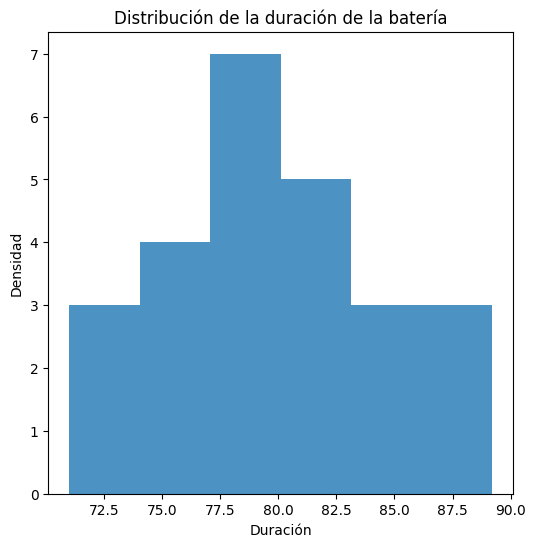

In [3]:
# Crear gráfico de densidad del array duraciones_conforme

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.hist(
    duraciones_conforme, 
    bins='sturges', 
    density=False, 
    alpha=0.8, 
    #color='blue'
    )
plt.xlabel('Duración')
plt.ylabel('Densidad')
plt.title('Distribución de la duración de la batería')
plt.show()


<>:61: SyntaxWarning: invalid escape sequence '\p'
<>:61: SyntaxWarning: invalid escape sequence '\p'
C:\Users\jhquiza\AppData\Local\Temp\ipykernel_17664\3822993552.py:61: SyntaxWarning: invalid escape sequence '\p'
  ax2.axvline(-t_crit, color='#b91c1c', linestyle=':', label=f'$t$ crítico = $\pm${t_crit:.3f}')


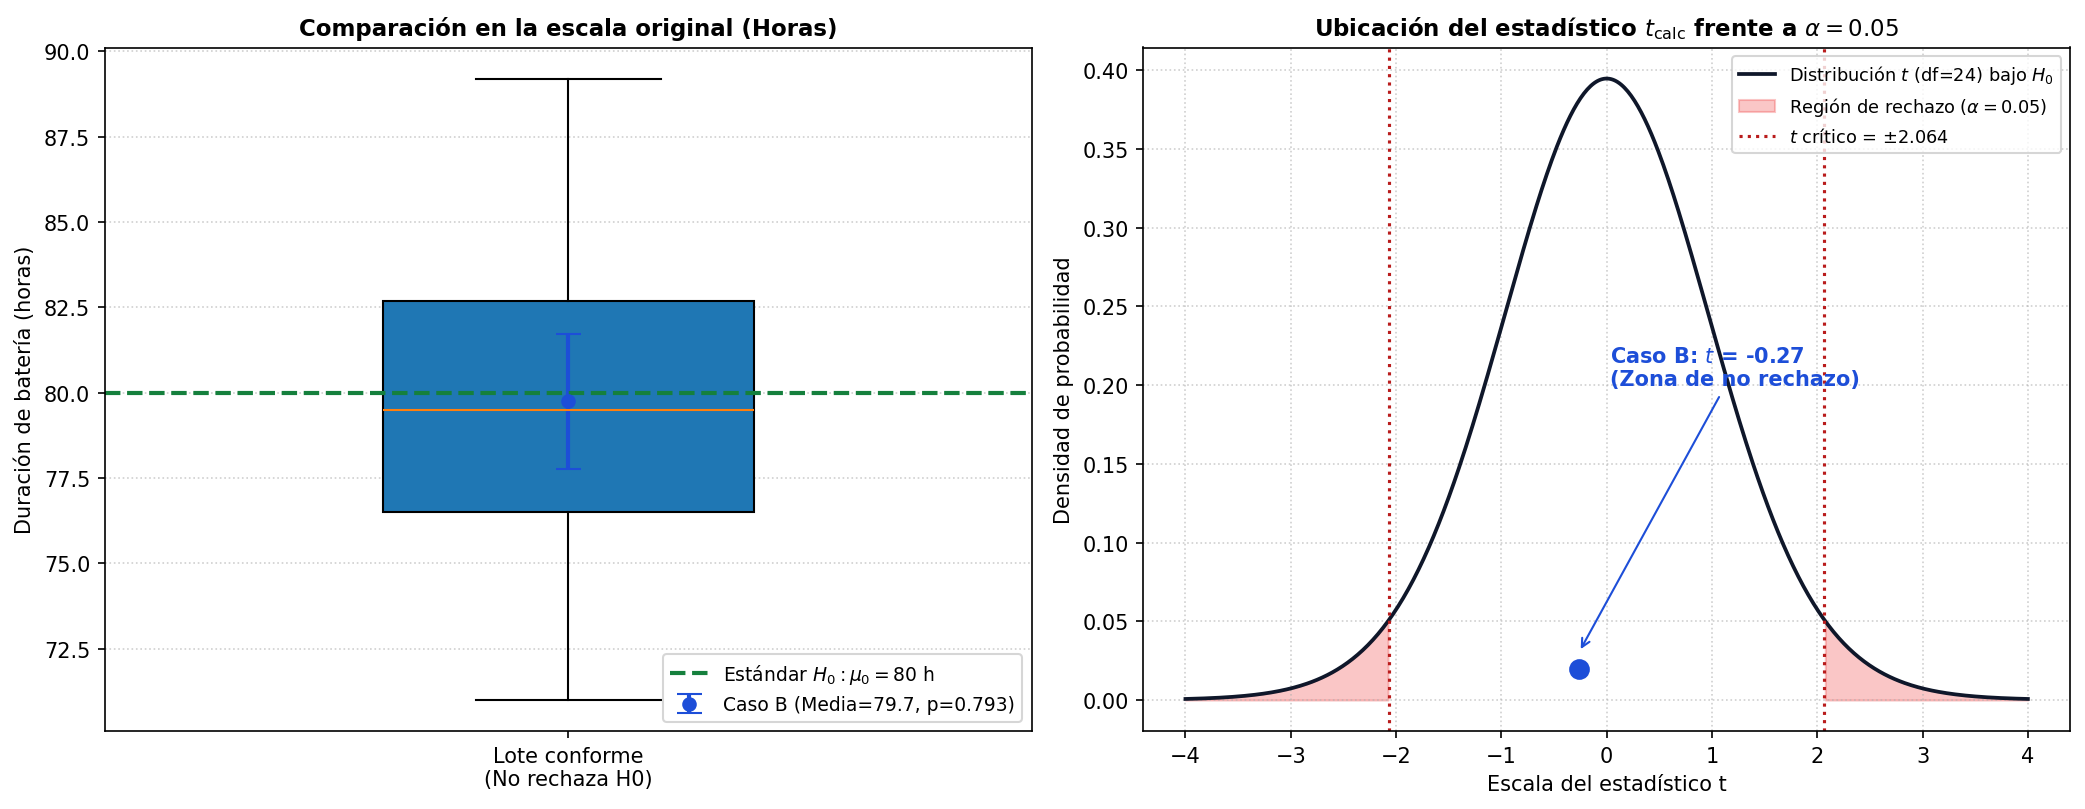

In [10]:
import scipy.stats as stats
import matplotlib.pyplot as plt


lote_conforme = np.array([
    71.0, 72.4, 73.5, 74.2, 75.0, 75.8, 76.5, 77.2, 77.9, 78.4,
    78.9, 79.2, 79.5, 79.8, 80.2, 80.6, 81.1, 81.9, 82.7, 83.5,
    84.6, 85.8, 86.9, 87.8, 89.2
])

mu_0 = 80.0
df = len(lote_conforme) - 1
t_crit = stats.t.ppf(0.975, df)

# Estadísticos
t_b, p_b = stats.ttest_1samp(lote_conforme, mu_0)

# 2. Construcción del gráfico comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=150)

# --- Panel 1: Estimaciones puntuales e Intervalos del 95% ---
mean_b, se_b = np.mean(lote_conforme), stats.sem(lote_conforme)

# Diagrama de cajas ligero
ax1.boxplot(
    [lote_conforme], 
    #positions=[1, 2], 
    widths=0.4,
    patch_artist=True, 
    #$boxprops=dict(facecolor='#f1f5f9', color='#64748b'),
    #medianprops=dict(color='#0f172a', linewidth=1.5)
    )

# Intervalos de confianza al 95% (t-Student)
#ax1.errorbar([1], [mean_a], yerr=[t_crit * se_a], fmt='o', color='#b91c1c', 
#             capsize=6, elinewidth=2, label=f'Caso A (Media={mean_a:.1f}, p={p_a:.3f})')
ax1.errorbar([1], [mean_b], yerr=[t_crit * se_b], fmt='o', color='#1d4ed8', 
             capsize=6, elinewidth=2, label=f'Caso B (Media={mean_b:.1f}, p={p_b:.3f})')

# Línea de referencia H0
ax1.axhline(mu_0, color='#15803d', linestyle='--', linewidth=2, label=r'Estándar $H_0: \mu_0 = 80$ h')

ax1.set_title("Comparación en la escala original (Horas)", fontsize=11, fontweight='bold')
ax1.set_xticks([1])
ax1.set_xticklabels(["Lote conforme\n(No rechaza H0)"])
ax1.set_ylabel("Duración de batería (horas)")
ax1.grid(axis='y', linestyle=':', alpha=0.6)
ax1.legend(loc='lower right', frameon=True, fontsize=9)

# --- Panel 2: Posición en la distribución teórica nula t(24) ---
x = np.linspace(-4, 4, 500)
y = stats.t.pdf(x, df)

ax2.plot(x, y, color='#0f172a', linewidth=1.8, label=f'Distribución $t$ (df={df}) bajo $H_0$')

# Sombreado de regiones de rechazo (alpha = 0.05)
ax2.fill_between(x, y, where=(x <= -t_crit), color='#ef4444', alpha=0.3, label=r'Región de rechazo ($\alpha = 0.05$)')
ax2.fill_between(x, y, where=(x >= t_crit), color='#ef4444', alpha=0.3)

# Líneas de valor crítico
ax2.axvline(-t_crit, color='#b91c1c', linestyle=':', label=f'$t$ crítico = $\pm${t_crit:.3f}')
ax2.axvline(t_crit, color='#b91c1c', linestyle=':')

# Ubicación de los estadísticos calculados
#ax2.scatter(t_a, 0.02, color='#b91c1c', s=80, zorder=5)
#ax2.annotate(f'Caso A: $t$ = {t_a:.2f}\n(Zona crítica)', xy=(t_a, 0.03), xytext=(t_a - 0.9, 0.12),
#             arrowprops=dict(arrowstyle="->", color='#b91c1c'), color='#b91c1c', fontweight='bold')

ax2.scatter(t_b, 0.02, color='#1d4ed8', s=80, zorder=5)
ax2.annotate(f'Caso B: $t$ = {t_b:.2f}\n(Zona de no rechazo)', xy=(t_b, 0.03), xytext=(t_b + 0.3, 0.20),
             arrowprops=dict(arrowstyle="->", color='#1d4ed8'), color='#1d4ed8', fontweight='bold')

ax2.set_title(r"Ubicación del estadístico $t_{\mathrm{calc}}$ frente a $\alpha = 0.05$", fontsize=11, fontweight='bold')
ax2.set_xlabel("Escala del estadístico t")
ax2.set_ylabel("Densidad de probabilidad")
ax2.grid(linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', frameon=True, fontsize=8.5)

plt.tight_layout()
plt.show()

<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:65: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_16500\3152914626.py:65: SyntaxWarning: invalid escape sequence '\p'
  ax2.axvline(-t_crit, color='#b91c1c', linestyle=':', label=f'$t$ crítico = $\pm${t_crit:.3f}')


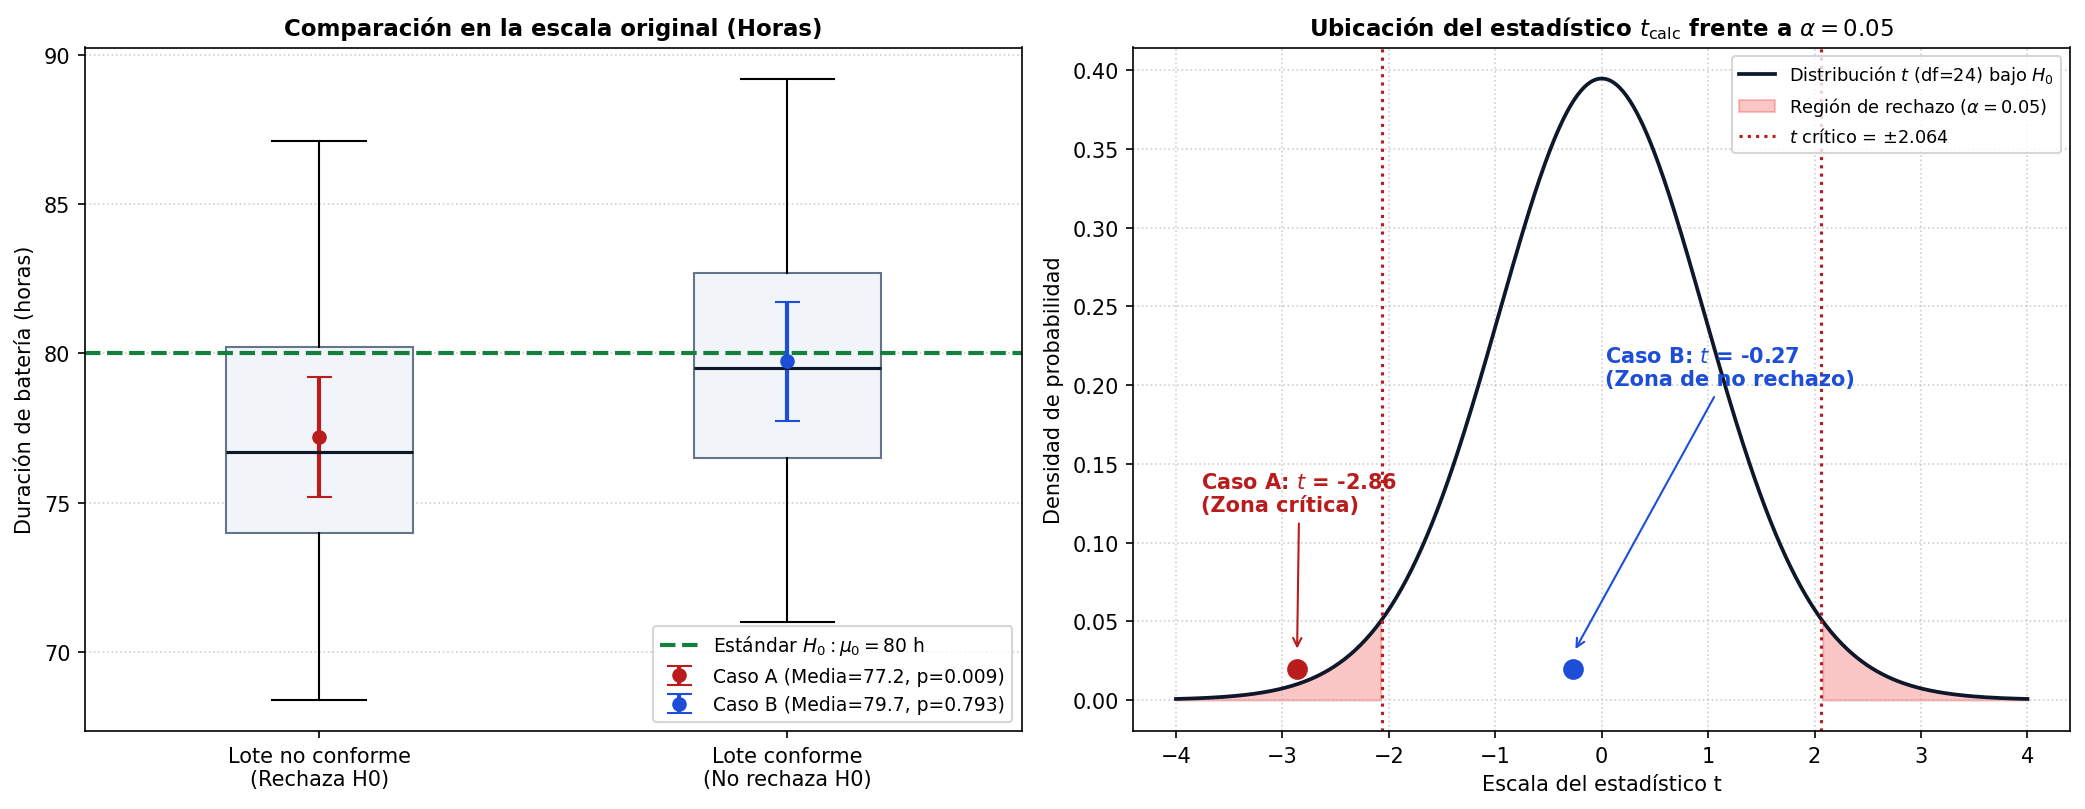

In [3]:
import scipy.stats as stats
import matplotlib.pyplot as plt


# 1. Datos de los dos casos
lote_rechazo = np.array([
    68.4, 69.8, 71.2, 72.0, 72.5, 73.1, 74.0, 74.8, 75.2, 75.9,
    76.1, 76.4, 76.7, 77.0, 77.3, 78.1, 78.5, 79.0, 80.2, 81.4,
    82.0, 83.3, 84.5, 85.6, 87.1
])

lote_conforme = np.array([
    71.0, 72.4, 73.5, 74.2, 75.0, 75.8, 76.5, 77.2, 77.9, 78.4,
    78.9, 79.2, 79.5, 79.8, 80.2, 80.6, 81.1, 81.9, 82.7, 83.5,
    84.6, 85.8, 86.9, 87.8, 89.2
])

mu_0 = 80.0
df = len(lote_rechazo) - 1
t_crit = stats.t.ppf(0.975, df)

# Estadísticos
t_a, p_a = stats.ttest_1samp(lote_rechazo, mu_0)
t_b, p_b = stats.ttest_1samp(lote_conforme, mu_0)

# 2. Construcción del gráfico comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=150)

# --- Panel 1: Estimaciones puntuales e Intervalos del 95% ---
mean_a, se_a = np.mean(lote_rechazo), stats.sem(lote_rechazo)
mean_b, se_b = np.mean(lote_conforme), stats.sem(lote_conforme)

# Diagrama de cajas ligero
ax1.boxplot([lote_rechazo, lote_conforme], positions=[1, 2], widths=0.4,
            patch_artist=True, boxprops=dict(facecolor='#f1f5f9', color='#64748b'),
            medianprops=dict(color='#0f172a', linewidth=1.5))

# Intervalos de confianza al 95% (t-Student)
ax1.errorbar([1], [mean_a], yerr=[t_crit * se_a], fmt='o', color='#b91c1c', 
             capsize=6, elinewidth=2, label=f'Caso A (Media={mean_a:.1f}, p={p_a:.3f})')
ax1.errorbar([2], [mean_b], yerr=[t_crit * se_b], fmt='o', color='#1d4ed8', 
             capsize=6, elinewidth=2, label=f'Caso B (Media={mean_b:.1f}, p={p_b:.3f})')

# Línea de referencia H0
ax1.axhline(mu_0, color='#15803d', linestyle='--', linewidth=2, label=r'Estándar $H_0: \mu_0 = 80$ h')

ax1.set_title("Comparación en la escala original (Horas)", fontsize=11, fontweight='bold')
ax1.set_xticks([1, 2])
ax1.set_xticklabels(["Lote no conforme\n(Rechaza H0)", "Lote conforme\n(No rechaza H0)"])
ax1.set_ylabel("Duración de batería (horas)")
ax1.grid(axis='y', linestyle=':', alpha=0.6)
ax1.legend(loc='lower right', frameon=True, fontsize=9)

# --- Panel 2: Posición en la distribución teórica nula t(24) ---
x = np.linspace(-4, 4, 500)
y = stats.t.pdf(x, df)

ax2.plot(x, y, color='#0f172a', linewidth=1.8, label=f'Distribución $t$ (df={df}) bajo $H_0$')

# Sombreado de regiones de rechazo (alpha = 0.05)
ax2.fill_between(x, y, where=(x <= -t_crit), color='#ef4444', alpha=0.3, label=r'Región de rechazo ($\alpha = 0.05$)')
ax2.fill_between(x, y, where=(x >= t_crit), color='#ef4444', alpha=0.3)

# Líneas de valor crítico
ax2.axvline(-t_crit, color='#b91c1c', linestyle=':', label=f'$t$ crítico = $\pm${t_crit:.3f}')
ax2.axvline(t_crit, color='#b91c1c', linestyle=':')

# Ubicación de los estadísticos calculados
ax2.scatter(t_a, 0.02, color='#b91c1c', s=80, zorder=5)
ax2.annotate(f'Caso A: $t$ = {t_a:.2f}\n(Zona crítica)', xy=(t_a, 0.03), xytext=(t_a - 0.9, 0.12),
             arrowprops=dict(arrowstyle="->", color='#b91c1c'), color='#b91c1c', fontweight='bold')

ax2.scatter(t_b, 0.02, color='#1d4ed8', s=80, zorder=5)
ax2.annotate(f'Caso B: $t$ = {t_b:.2f}\n(Zona de no rechazo)', xy=(t_b, 0.03), xytext=(t_b + 0.3, 0.20),
             arrowprops=dict(arrowstyle="->", color='#1d4ed8'), color='#1d4ed8', fontweight='bold')

ax2.set_title(r"Ubicación del estadístico $t_{\mathrm{calc}}$ frente a $\alpha = 0.05$", fontsize=11, fontweight='bold')
ax2.set_xlabel("Escala del estadístico t")
ax2.set_ylabel("Densidad de probabilidad")
ax2.grid(linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', frameon=True, fontsize=8.5)

plt.tight_layout()
plt.show()